<a href="https://colab.research.google.com/github/fadeeva/nakedML/blob/master/MLnotes/004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd

from scipy import stats
from scipy.spatial import distance_matrix
from scipy.sparse.csgraph import connected_components
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.cluster.hierarchy import fclusterdata, linkage, fcluster

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [19]:
rng = np.random.default_rng()

In [20]:
df = pd.read_csv(f'{path}/Mall_Customers.csv')
df.drop(['CustomerID'], inplace=True, axis=1)

df.columns = [col.strip().lower() for col in df.columns]
df = df.rename(columns={
    'annual income (k$)': 'income',
    'spending score (1-100)': 'score'
})

mask = {'Male': 0, 'Female': 1}
df['gender'] = df['gender'].map(mask)

df.head()

,gender,age,income,score
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


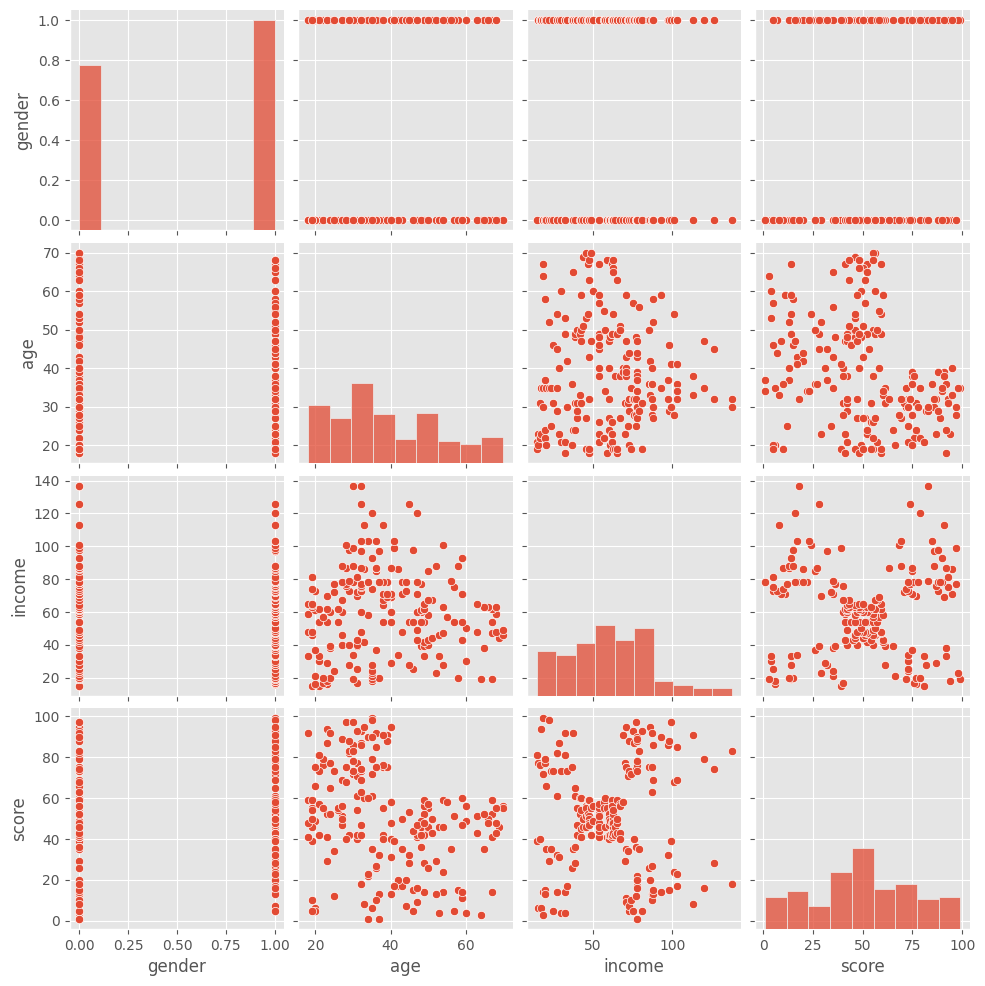

In [21]:
sns.pairplot(df)

# 04/

# Clustering



**Purpose / Why it's used:**

 - To measure the degree of similarity between objects.
 - To speed up further data processing.
 - To reduce the volume of stored data.
 - To detect outliers.
 - For feature selection (selecting one representative feature from each cluster).

**If an algorithm uses a distance metric on a set of objects, then the values of all features must be normalized beforehand.**


In [22]:
standrtzt = lambda row: (row - row.mean()) / row.std() # normalization
em_distance = lambda p, q: np.round(np.sqrt(np.sum((p - q) ** 2)), 3)

def em_distance_pairs(data): # i don't use it because it's extremly sloooooooooooow
    n = data.shape[0]
    dist = np.zeros((n, n))

    for i in range(n):
        for j in range(i+1, n):
            d = em_distance(data.iloc[i], data.iloc[j])
            dist[i, j], dist[j, i] = d, d

    return dist


## Threshold-based Clustering

Best suited for:

1. **Data with clear, dense clusters.** The method works well when clusters are
well-separated and have roughly equal density.

2. **Small to medium datasets.** With n > 10,000 objects, the algorithm becomes too computationally expensive.

3. **Low-dimensional data (2–10 features).** In high-dimensional spaces, the concept of "closeness" becomes meaningless, and the method loses its effectiveness.

4. **Outlier detection.** Objects for which all edges are longer than the threshold remain isolated. This automatically marks them as potential outliers.

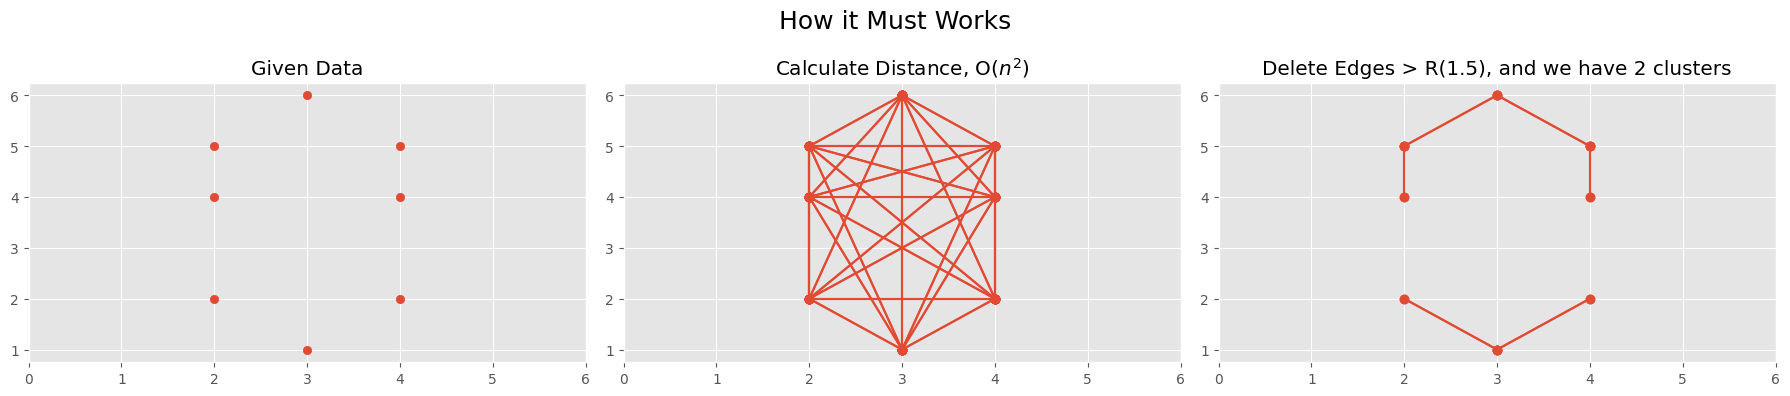

In [23]:
data = np.array([
    [2, 3, 4, 4, 4, 3, 2, 2],
    [5, 6, 5, 4, 2, 1, 2, 4]
])

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

axs[0].scatter(data[0], data[1])
axs[0].set_xlim(0, 6)
axs[0].set_title('Given Data')

for i in range(len(data[0])):
    for j in range(len(data[0])):
        if i==j: continue

        X = [data[0][i], data[0][j]]
        Y = [data[1][i], data[1][j]]
        axs[1].plot(X, Y, marker='o', c='#E24A33')

axs[1].set_xlim(0, 6)
axs[1].set_title(r'Calculate Distance, O($n^2$)')

R = 1.5
for i in range(len(data[0])):
    for j in range(len(data[0])):
        dot_1 = np.array([data[0][i], data[1][i]])
        dot_2 = np.array([data[0][j], data[1][j]])
        dist = em_distance(dot_1, dot_2)

        if i==j or dist > R: continue

        X = [data[0][i], data[0][j]]
        Y = [data[1][i], data[1][j]]
        axs[2].plot(X, Y, marker='o', c='#E24A33')

axs[2].set_xlim(0, 6)
axs[2].set_title(f'Delete Edges > R({R}), and we have 2 clusters')

fig.suptitle('How it Must Works', fontsize=18)
plt.tight_layout()

In [24]:
features = [
    'score',
    'income',
]

clust_al_1 = df[features].copy()

clust_al_1[features[0]] = standrtzt(clust_al_1[features[0]])
clust_al_1[features[1]] = standrtzt(clust_al_1[features[1]])

clust_al_1_dist = distance_matrix(clust_al_1.values, clust_al_1.values)

threshold = .5
clust_al_1_dist[clust_al_1_dist > threshold] = np.nan
np.fill_diagonal(clust_al_1_dist, np.nan)
clust_al_1_dist = np.round(clust_al_1_dist, 2)

adj_matrix = np.where(~np.isnan(clust_al_1_dist), 1, 0)
n_components, labels = connected_components(csgraph=adj_matrix, directed=False)

print(f'Number of Clusters: {n_components}')

Number of Clusters: 7


In [25]:
clust_al_1['cluster'] = labels
clust_al_1.groupby('cluster').count()

,score,income
cluster,,
0,157,157
1,36,36
2,2,2
3,2,2
4,1,1
5,1,1
6,1,1


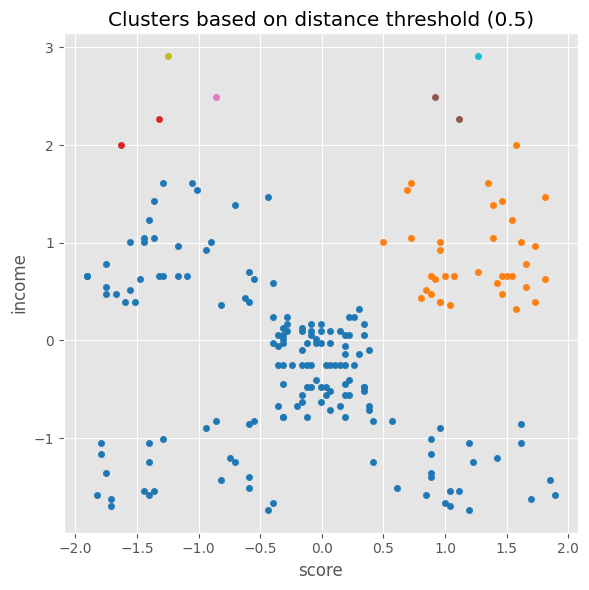

In [26]:
plt.figure(figsize=(6, 6))

colors = plt.cm.tab10(np.linspace(0, 1, n_components))

for cluster_id in range(n_components):
    subset = clust_al_1[clust_al_1['cluster'] == cluster_id]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=20, marker='o', color=colors[cluster_id])

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'Clusters based on distance threshold ({threshold})')
plt.tight_layout()

## Minimum Spanning Tree (MST) based Clusterisation

Best suited for:

1. **Detecting clusters of arbitrary and complex shapes** (e.g., spirals, connected
line segments, or non-convex blobs), unlike methods like K-means which assume spherical clusters.

2. **Partitioning data without being constrained to specific cluster shapes**, allowing for more flexible and natural data grouping.

3. **Handling low-dimensional data** (e.g., biological or image data) where they can be very competitive with other state-of-the-art algorithms.

4. **Identifying well-separated, relatively dense clusters.**

5. **Studying functional relationships** in genes and other applications in bioinformatics.

6. **Recognizing patterns in images.**

7. **Detecting anomalies** by being more sensitive to the underlying data manifold structure than traditional distance metrics.

8. **Solving cluster identification problems on large datasets**, particularly when using a parallel implementation for efficiency.

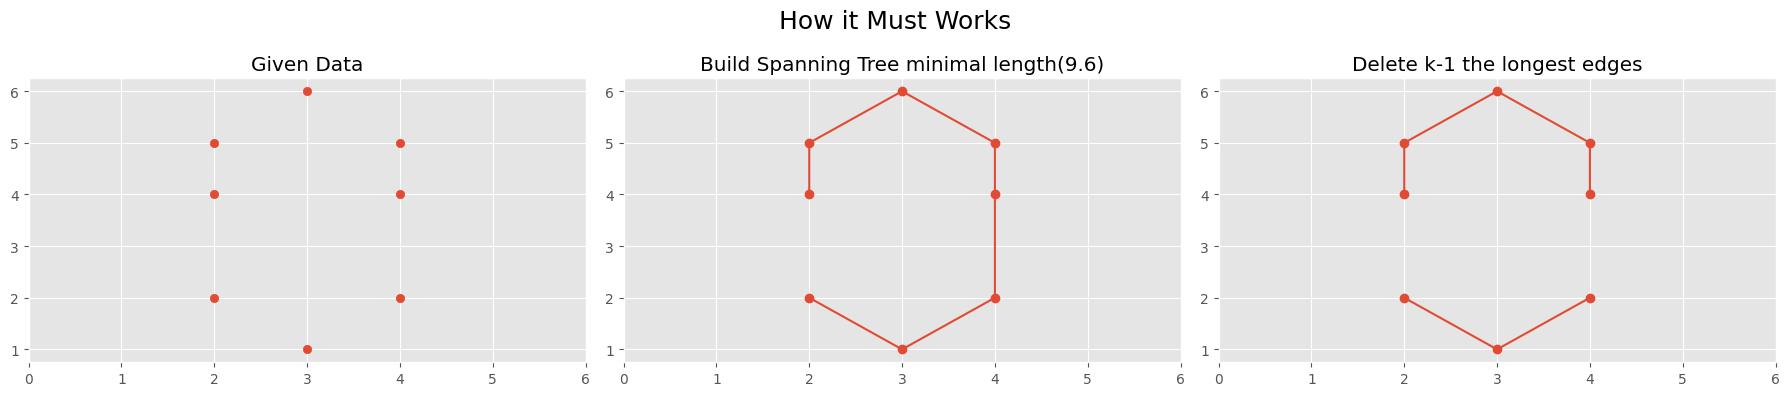

In [33]:
data = np.array([
    [2, 3, 4, 4, 4, 3, 2, 2],
    [5, 6, 5, 4, 2, 1, 2, 4]
])

k = 2 # number of clusters

fig, axs = plt.subplots(1, 3, figsize=(18, 4))

axs[0].scatter(data[0], data[1])
axs[0].set_xlim(0, 6)
axs[0].set_title('Given Data')

axs[1].plot(
    [2, 2, 3, 4, 4, 4, 3, 2],
    [4, 5, 6, 5, 4, 2, 1, 2],
    marker='o', c='#E24A33')

axs[1].set_xlim(0, 6)
axs[1].set_title('Build Spanning Tree minimal length(9.6)')

axs[2].plot(
    [2, 2, 3, 4, 4],
    [4, 5, 6, 5, 4],
    marker='o', c='#E24A33')
axs[2].plot(
    [4, 3, 2],
    [2, 1, 2],
    marker='o', c='#E24A33')

axs[2].set_xlim(0, 6)
axs[2].set_title(f'Delete k-1 the longest edges')

fig.suptitle('How it Must Works', fontsize=18)
plt.tight_layout()

In [35]:
clust_al_2 = df[features].copy()

clust_al_2[features[0]] = standrtzt(clust_al_2[features[0]])
clust_al_2[features[1]] = standrtzt(clust_al_2[features[1]])

clust_al_2_dist = distance_matrix(clust_al_2.values, clust_al_2.values)
mst_matrix = minimum_spanning_tree(clust_al_2_dist)
mst_dense = mst_matrix.toarray().astype(float)

edges = []
n = clust_al_2.shape[0]
for i in range(n):
    for j in range(i+1, n):
        if mst_dense[i, j] > 0:
            edges.append((mst_dense[i, j], i, j))

edges_sorted = sorted(edges, key=lambda x: x[0], reverse=True)

k = 20
edges_to_remove = edges_sorted[:k-1]

mst_filtered = mst_dense.copy()
for weight, i, j in edges_to_remove:
    mst_filtered[i, j] = 0
    mst_filtered[j, i] = 0

n_components, labels = connected_components(csgraph=mst_filtered, directed=False)

clust_al_2['cluster'] = labels

print(f'spanning tree length = {np.round(mst_matrix.sum(), 2)}')

spanning tree length = 29.59


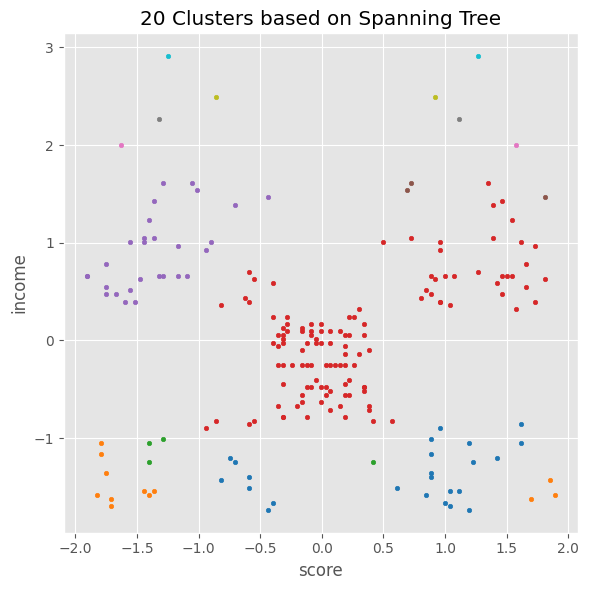

In [28]:
plt.figure(figsize=(6, 6))

colors = plt.cm.tab10(np.linspace(0, 1, n_components))

for cluster_id in range(n_components):
    subset = clust_al_2[clust_al_2['cluster'] == cluster_id]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=10, marker='o', color=colors[cluster_id])

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'{k} Clusters based on Spanning Tree')
plt.tight_layout()


In [37]:
clust_al_2.groupby('cluster').count().sort_values(by='score', ascending=False)

,score,income
cluster,,
6,89,89
7,32,32
8,26,26
1,17,17
2,9,9
0,7,7
3,3,3
4,3,3
11,2,2


## Single-Linkage Clustering

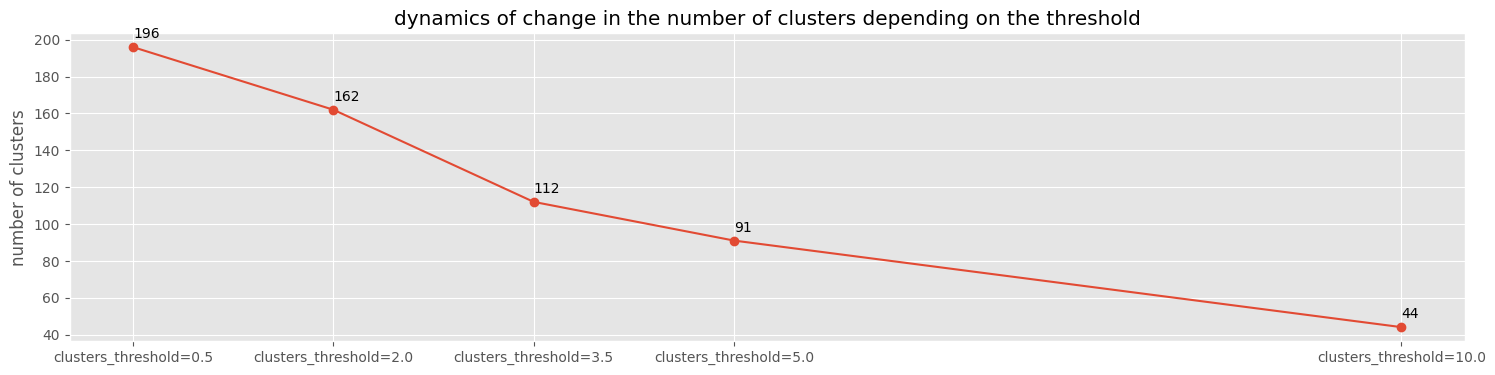

In [30]:
clust_sl = df[features].copy()
thresholds = [.5, 2.0, 3.5, 5.0, 10.0]

for t in thresholds:
    clust_sl[f'clusters_threshold={t}'] = fclusterdata(
        clust_sl, t=t,
        criterion='distance', method='single'
    )

plt.figure(figsize=(18, 4))

plt.plot(
    thresholds,
    clust_sl[[f'clusters_threshold={t}' for t in thresholds]].nunique().to_numpy(),
    marker='o'
)
plt.xticks(
    thresholds,
    clust_sl[[f'clusters_threshold={t}' for t in thresholds]].nunique().index
)

plt.ylabel('number of clusters')
plt.title('dynamics of change in the number of clusters depending on the threshold')

for t in thresholds:
    n_clusters = clust_sl[f'clusters_threshold={t}'].nunique()
    plt.annotate(
        text=n_clusters,
        xy=(t, n_clusters),
        xytext=(t, n_clusters+5),
    )


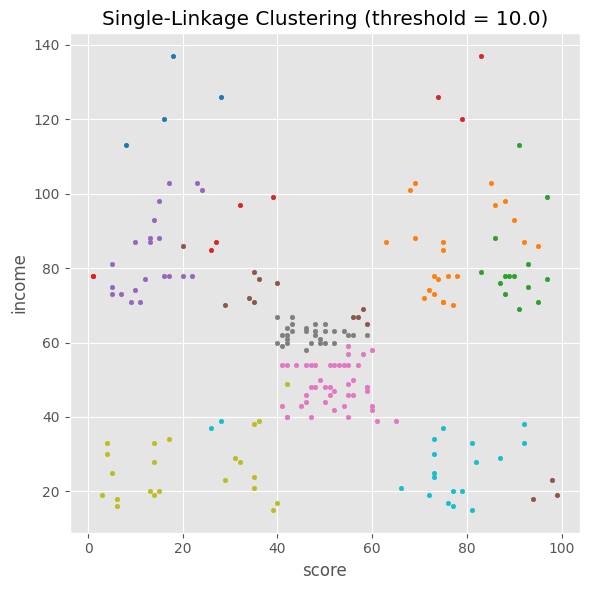

In [31]:
n_components = clust_sl['clusters_threshold=10.0'].nunique()

plt.figure(figsize=(6, 6))

colors = plt.cm.tab10(np.linspace(0, 1, n_components))

for cluster_id in range(n_components):
    subset = clust_sl[clust_sl['clusters_threshold=10.0'] == cluster_id]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=10, marker='o', color=colors[cluster_id])

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title('Single-Linkage Clustering (threshold = 10.0)')
plt.tight_layout()

## "maxclust" Criterion

Partitioning the Dendrogram to Obtain a Specified Number of clusters

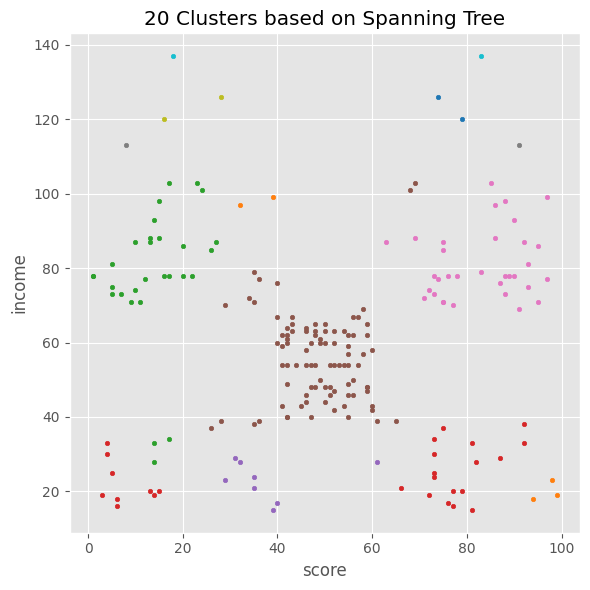

In [32]:
clust_al_2_lib = df[features].copy()

Z = linkage(clust_al_2_lib, method='single')

k = 20
clust_al_2_lib['clusters'] = fcluster(Z, t=k, criterion='maxclust')

plt.figure(figsize=(6, 6))

colors = plt.cm.tab10(np.linspace(0, 1, k))

for cluster_id in range(k):
    subset = clust_al_2_lib[clust_al_2_lib['clusters'] == cluster_id]
    plt.scatter(subset[features[0]], subset[features[1]],
                s=10, marker='o', color=colors[cluster_id])

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(f'{k} Clusters based on Spanning Tree')
plt.tight_layout()